In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 모델링
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgbm
from catboost import CatBoostRegressor

# 평가지표
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# 파이프라인
from sklearn.pipeline import Pipeline

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)
random_seed = 42

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [2]:
os.chdir(os.path.abspath('..'))
print(os.getcwd())

c:\Users\chanhyeok\Desktop\lucky7\airbnb_price_prediction


In [4]:
# 이 경로에서 원하는 데이터로 변경
def load_borough_data(base_path, borough_name):
    """
    특정 자치구 폴더에서 6개의 CSV 파일을 로드하여 반환합니다.
    """
    
    if borough_name == 'manhattan':
        suffix = 'mnh'
    elif borough_name == 'brooklyn':
        suffix = 'bkl'
    else:
        suffix = borough_name

    path = f'{base_path}/{borough_name}'
    
    X_train = pd.read_csv(f'{path}/X_train_{suffix}.csv')
    y_train = pd.read_csv(f'{path}/y_train_{suffix}.csv').squeeze()
    X_test = pd.read_csv(f'{path}/X_test_{suffix}.csv')
    y_test = pd.read_csv(f'{path}/y_test_{suffix}.csv').squeeze()
    ids_train = pd.read_csv(f'{path}/ids_train_{suffix}.csv')
    ids_test = pd.read_csv(f'{path}/ids_test_{suffix}.csv')
    
    return X_train, y_train, X_test, y_test, ids_train, ids_test

base = 'data'

# 보고 싶은 파트를 바꾸면 됨!
X_train, y_train, X_test, y_test, ids_train, ids_test = load_borough_data(base, 'brooklyn')

In [5]:
xgb_reg = xgb.XGBRegressor(
    random_state = random_seed,
    n_jobs = -1,
    verbosity = 1,
    tree_method = 'hist'
)

# 우리는 요정도만! 설정해볼까요? + 처음에 n_estimators를 작게하고 다른 것들을 좁혀나가다가, n_estimators를 늘려가는 식으로가 팁!
# 우선 100 ~ 300으로 하다가, 어느 정도 된 거 같으면 n_estimator 늘려보기
# 다중공선성 체크 안 하고 변수 다 때려넣었으니, L1 규제(유의미하지 않으면 0으로 만드는 규제) 사용해보기
# 과적합 우려가 높기 때문에, min_child_weight 사용해보기
param_grid = {
    'n_estimators' : [300,500,600],
    'max_depth' : [5,7,10],
    'learning_rate' : [0.03,0.05, 0.1],
    'subsample' : [0.8,1],
    'colsample_bytree' : [0.8, 1],
    'min_child_weight' : [3,8],
    'alpha' : [0.1,1,5]
}

# grid_cv = GridSearchCV(
#     estimator = xgb_reg,
#     param_grid = param_grid,
#     scoring = 'neg_mean_squared_error',
#     cv = 5,
#     n_jobs = -1,
#     verbose = 2,
#     return_train_score = True
# )

model_cv = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_grid, 
    n_iter=100,                     
    scoring='neg_mean_squared_error',
    cv=3,                          
    n_jobs=-1,
    verbose=3,
    return_train_score = True,
    random_state=random_seed,
)

model_cv.fit(X_train, y_train)
print(f'최적 파라미터 : {model_cv.best_params_}')
print(f'최적 RMSE : {model_cv.best_score_}')

Fitting 3 folds for each of 100 candidates, totalling 300 fits
최적 파라미터 : {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 1, 'alpha': 0.1}
최적 RMSE : -0.1094672467532476


In [6]:
cv_df = pd.DataFrame(model_cv.cv_results_)[
    ["param_n_estimators", "param_max_depth","param_learning_rate",'param_subsample', 'param_colsample_bytree',
    'param_subsample','param_min_child_weight', 'param_alpha',
    "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]
].rename(columns={
    "param_n_estimators" : "n_estimators",
    "param_max_depth": "max_depth",
    "param_learning_rate" : 'learning_rate',
    "param_subsample" : "subsample",
    "param_colsample_bytree" : "colsample_bytree",
    "mean_train_score": "훈련 정확도",
    "mean_test_score": "검증 정확도",
    "std_test_score": "표준편차",
    "rank_test_score": "순위",
}).sort_values("순위")

cv_df.head(20)


# cv_df = pd.DataFrame(model_cv.cv_results_)[
#     ["param_n_estimators", "param_max_depth","param_learning_rate",'param_subsample', 'param_colsample_bytree',
#     'param_subsample','param_min_child_weight', 'param_lambda',
#     "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]
# ].rename(columns={
#     "param_n_estimators" : "n_estimators",
#     "param_max_depth": "max_depth",
#     "param_learning_rate" : 'learning_rate',
#     "param_subsample" : "subsample",
#     "param_colsample_bytree" : "colsample_bytree",
#     "mean_train_score": "훈련 정확도",
#     "mean_test_score": "검증 정확도",
#     "std_test_score": "표준편차",
#     "rank_test_score": "순위",
# }).sort_values("순위")

# cv_df.head(20)

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,subsample,param_min_child_weight,param_alpha,훈련 정확도,검증 정확도,표준편차,순위
36,500,5,0.03,0.8,1.0,0.8,3,0.1,-0.026334,-0.109467,0.004872,1
91,600,5,0.05,0.8,1.0,0.8,3,0.1,-0.008465,-0.109478,0.005372,2
45,500,5,0.03,0.8,0.8,0.8,3,0.1,-0.026922,-0.109567,0.005262,3
19,600,5,0.03,0.8,0.8,0.8,8,0.1,-0.024946,-0.109721,0.004935,4
1,600,5,0.03,0.8,0.8,0.8,3,1.0,-0.027095,-0.110108,0.004416,5
74,500,5,0.03,0.8,0.8,0.8,3,1.0,-0.032799,-0.110229,0.004487,6
16,500,5,0.05,0.8,1.0,0.8,3,1.0,-0.017562,-0.110308,0.004540,7
23,300,7,0.05,0.8,0.8,0.8,8,0.1,-0.007291,-0.110495,0.004851,8
64,600,5,0.05,0.8,1.0,0.8,3,1.0,-0.013591,-0.110655,0.004532,9
95,500,7,0.05,0.8,0.8,0.8,8,0.1,-0.001680,-0.110697,0.004765,10


In [7]:
best_model = model_cv.best_estimator_
pred_final = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_final))
rmse2 = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred_final)))
r2 = r2_score(y_test, pred_final)
mape = mean_absolute_percentage_error(np.expm1(y_test), np.expm1(pred_final))

print(f"교차검증 RMSE: {model_cv.best_score_:.3f}")
print(f"Log Root Mean Squared Error: {rmse:.3f}")
print(f"결정 계수 : {r2 * 100:.3f}%")
print()

print(f'원래 가격의 RMSE : {rmse2:.3f}')
print(f'원래 가격의 MAPE : {mape * 100:.3f}%')

교차검증 RMSE: -0.109
Log Root Mean Squared Error: 0.318
결정 계수 : 73.588%

원래 가격의 RMSE : 59.377
원래 가격의 MAPE : 25.559%


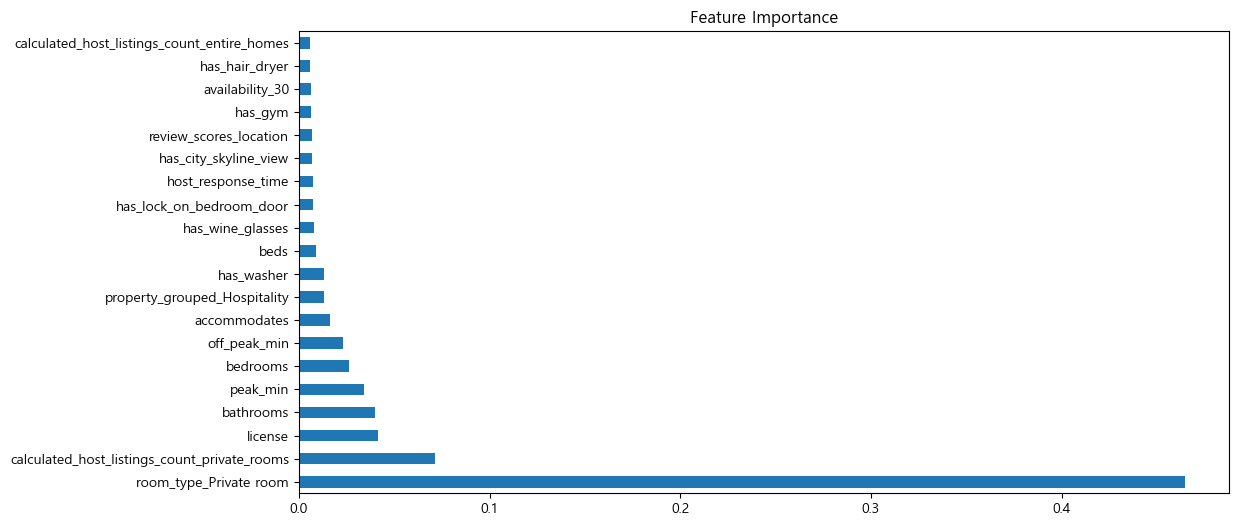

In [8]:
# 최적의 모델에서 피처 중요도 뽑기
import matplotlib.pyplot as plt

best_model = model_cv.best_estimator_
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(20).plot(kind='barh')
plt.title("Feature Importance")

plt.show()

In [20]:
# best_model은 XGBRegressor라고 가정
print(type(best_model))  # XGBRegressor인지 확인
print(best_model.get_booster())  # Booster 객체 확인

<class 'xgboost.sklearn.XGBRegressor'>


In [22]:
for col in X_test.columns:
    for i, val in enumerate(X_test[col].values):
        try:
            _ = float(val)
        except:
            print(f"Cannot convert to float at row {i}, column '{col}': {repr(val)}")

In [30]:
import matplotlib.pyplot as plt
import shap

best_model = model_cv.best_estimator_

explainer = shap.TreeExplainer(best_model.get_booster())
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

ValueError: could not convert string to float: '[4.8369102E0]'

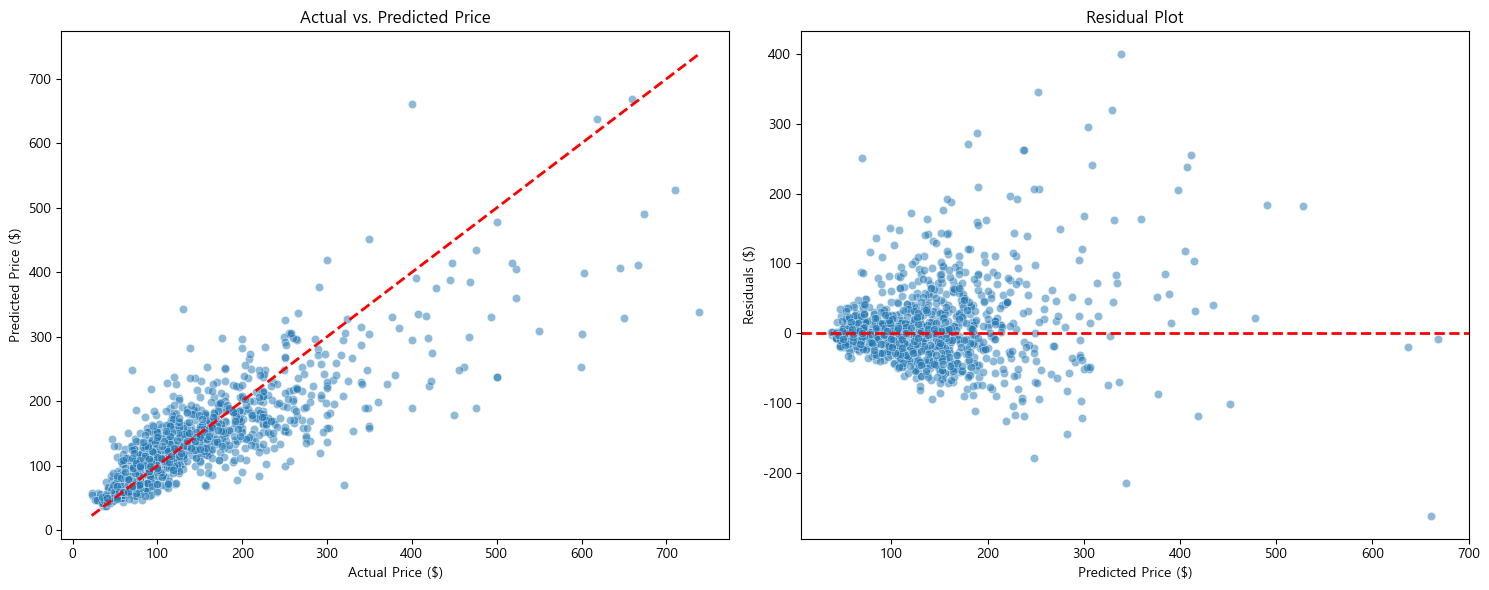

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 (로그 단위를 원본 달러 단위로 복원)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(pred_final)
residuals = y_test_orig - y_pred_orig

# 시각화 설정
plt.figure(figsize=(15, 6))

# 그래프 1: 실제값 vs 예측값 (Actual vs Predicted)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_orig, y=y_pred_orig, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs. Predicted Price')

# 그래프 2: 잔차도 (Residual Plot)
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_orig, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residuals ($)')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

In [69]:
X_train.select_dtypes(include='object').columns

Index([], dtype='str')

In [70]:
print(X_train.iloc[0])

description                                         1
host_location                                     4.0
host_about                                          0
host_response_time                                2.0
host_response_rate                                1.0
host_acceptance_rate                             0.83
host_is_superhost                                   0
host_listings_count                              10.0
host_total_listings_count                        11.0
host_has_profile_pic                                1
neighbourhood                                       0
accommodates                                      3.0
bathrooms                                         1.0
bedrooms                                          1.0
beds                                              1.0
off_peak_min                                     30.0
peak_min                                         30.0
peak_max                                        365.0
off_peak_max                

In [ ]:
# best_model = model_cv.best_estimator_
# best_model.save_model('xgb_model_brooklyn.json') # -> 여기 저장하고 싶은 이름으로 바꾸기!

# 나중에 불러올 때 쓰는 함수
# loaded_model = xgb.XGBRegressor() # 객체 먼저 생성
# loaded_model.load_model('xgb_model.json')

In [14]:
# 컬럼별로 리스트/배열이 들어 있는지 확인
for col in X_test.columns:
    if X_test[col].apply(lambda x: isinstance(x, (list, np.ndarray))).any():
        print(f"List/array found in column: {col}")

In [15]:
# '[숫자]' 형태 문자열 확인
for col in X_test.columns:
    if X_test[col].apply(lambda x: isinstance(x, str) and x.startswith("[") and x.endswith("]")).any():
        print(f"Stringified list found in column: {col}")

In [36]:
obj_cols = X_test.select_dtypes(include='object').columns
for col in obj_cols:
    print(f"\nColumn: {col}")
    print(X_test[col].head(10))

In [17]:
def is_convertible_to_float(x):
    try:
        float(x)
        return True
    except:
        return False

for col in obj_cols:
    mask = ~X_test[col].apply(is_convertible_to_float)
    if mask.any():
        print(f"Cannot convert to float in column: {col}")
        print(X_test[col][mask].head(10))

In [18]:
# 문제 있는 셀 찾기
for col in X_test.columns:
    for i, val in enumerate(X_test[col]):
        try:
            float(val)  # float 변환 시도
        except:
            print(f"Cannot convert to float at row {i}, column '{col}': {repr(val)}")

In [19]:
# X_test 전체에서 object 타입 셀 구조 확인
for col in X_test.columns:
    for i, val in enumerate(X_test[col]):
        if isinstance(val, np.ndarray):
            print(f"Row {i}, Column '{col}' is np.ndarray with shape {val.shape}, dtype={val.dtype}, value={val}")
        elif isinstance(val, list):
            print(f"Row {i}, Column '{col}' is list with length {len(val)}, value={val}")
        elif isinstance(val, str) and val.startswith('[') and val.endswith(']'):
            print(f"Row {i}, Column '{col}' is stringified list: {val}")

In [24]:
# 문제 있는 셀을 기록할 리스트
problem_cells = []

# X_test 전체를 스캔
for col in X_test.columns:
    for i, val in enumerate(X_test[col].values):
        # 1. float 변환 시도
        can_float = True
        try:
            float(val)
        except:
            can_float = False
        
        # 2. numpy array인지, list인지, shape 확인
        val_type = type(val)
        val_shape = getattr(val, 'shape', None)
        
        # 3. 문제 조건: float 변환 불가이거나, numpy array / list / object 구조
        if not can_float or isinstance(val, (np.ndarray, list)):
            problem_cells.append({
                'row': i,
                'column': col,
                'type': val_type,
                'shape': val_shape,
                'repr': repr(val)
            })

# 결과 출력
if problem_cells:
    df_problems = pd.DataFrame(problem_cells)
    print("Problematic cells found:")
    print(df_problems)
else:
    print("No problematic cells detected. 모든 셀 float 변환 가능")

No problematic cells detected. 모든 셀 float 변환 가능


In [ ]:
# import shap

# # X_test가 이미 float 형태라면 그냥 그대로 사용
# X_test_clean = X_test.astype(float)  # 각 셀을 강제로 float로 변환

# # TreeExplainer 생성
# explainer = shap.TreeExplainer(best_model)

# # SHAP 값 계산
# shap_values = explainer.shap_values(X_test_clean)

# # summary plot
# shap.summary_plot(shap_values, X_test_clean, plot_type="bar")

ValueError: could not convert string to float: '[4.8369102E0]'